In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def get_relaxation_time(f, t):
    tau = np.interp(1 / np.e, f[::-1], t[::-1])
    if not np.min(f) < 1 / np.e:
        return np.nan
    return tau

def get_diffusion_coeff(m, t, dim=2, scale=1):
    mask = t < t.max() / (10 * scale)
    c = np.mean(np.log10(m) - np.log10(t))
    return (10 ** c) / (2 * dim)

In [204]:
dp_data = np.load('data/dp-dynamics-data-3.npz', allow_pickle=True)
ga_data = np.load('data/ga-dynamics-data-3.npz', allow_pickle=True)
ga_density_data = np.load('data/ga-densities.npz', allow_pickle=True)
ga_jam_data = np.load('data/ga-jam-2d.npz', allow_pickle=True)
sphere_data = np.load('data/sphere-dynamics-data-3.npz', allow_pickle=True)

def get_ga_conversion(ga_density_data, mu, alpha, nv):
    mask = (ga_density_data['nv'] == nv) & (ga_density_data['mu'] == mu) & (ga_density_data['alpha'] == alpha)
    return (ga_density_data['true_phi'] / ga_density_data['phi'])[mask][0]

ga_data_true_phi = np.array([get_ga_conversion(ga_density_data, mu, alpha, nv) * phi for mu, alpha, nv, phi in zip(
    ga_data['mu'], ga_data['alpha'], ga_data['nv'], ga_data['phi']
)])

ga_jam_data_true_phi = np.array([get_ga_conversion(ga_density_data, mu, alpha, nv) * phi for mu, alpha, nv, phi in zip(
    ga_jam_data['mu'], ga_jam_data['alpha'], ga_jam_data['nv'], ga_jam_data['phi']
)])

ga_min_save_decade = 1_000
dp_min_save_decade = 1_000
sphere_min_save_decade_map = {
    '1': 1_000,
    '2': 100,
    '3': 10,
}
sphere_min_save_decade = np.array([sphere_min_save_decade_map[str(w).split('_')[-1]] for w in sphere_data['which']])

# GA Jamming Data

/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_55392/3267139286.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([mu] * len(phis), phis, s=1, c=cmap(alpha_norm(alpha)))


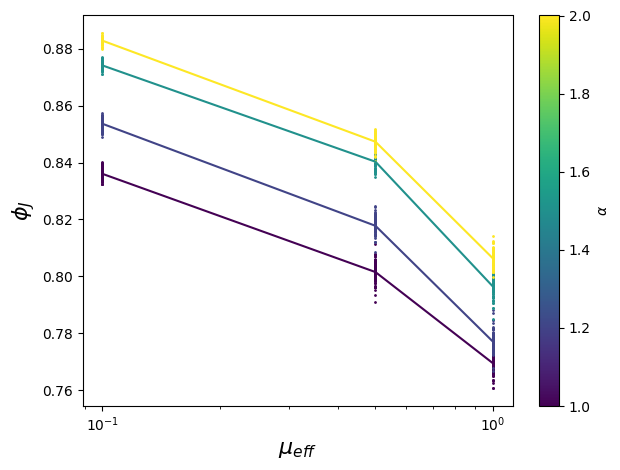

In [224]:
alpha_norm = plt.Normalize(min(ga_data['alpha']), max(ga_data['alpha']))
cmap = plt.cm.viridis

for alpha in np.unique(ga_data['alpha']):
    x, y = [], []
    for mu in np.unique(ga_data['mu']):

        ga_jam_data_mask = (ga_jam_data['mu'] == mu) & (ga_jam_data['alpha'] == alpha)
        phis = ga_jam_data_true_phi[ga_jam_data_mask]
        plt.scatter([mu] * len(phis), phis, s=1, c=cmap(alpha_norm(alpha)))
        
        x.append(mu)
        y.append(np.mean(phis))
    
    plt.plot(x, y, c=cmap(alpha_norm(alpha)))
plt.xscale('log')
plt.xlabel(r'$\mu_{eff}$', fontsize=16)
plt.ylabel(r'$\phi_J$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=alpha_norm, cmap=cmap)
sm.set_array(np.unique(ga_data['alpha']))
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\alpha$')

plt.tight_layout()
plt.savefig('figures/ga/phi-j.png', dpi=600)

# GA Dynamics Data

/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_55392/775425389.py:17: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[0].scatter(ga_data_true_phi[ga_data_mask], ga_tau[ga_data_mask], c=cmap(mu_norm(mu)), s=10, marker='o')
/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_55392/775425389.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[0].scatter(ga_data_true_phi[ga_data_mask], ga_tau_R[ga_data_ma

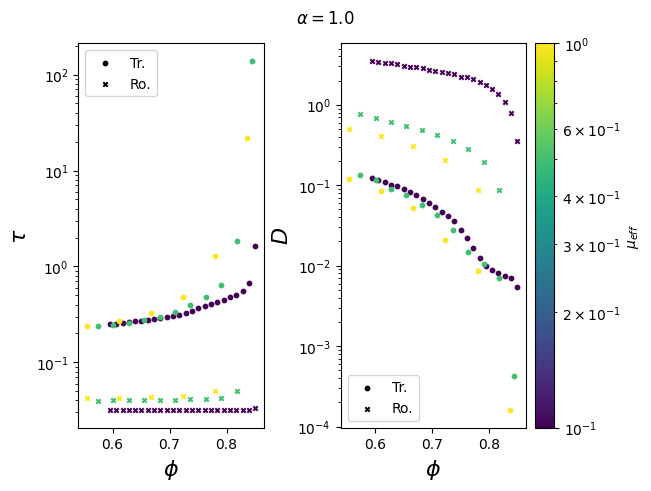

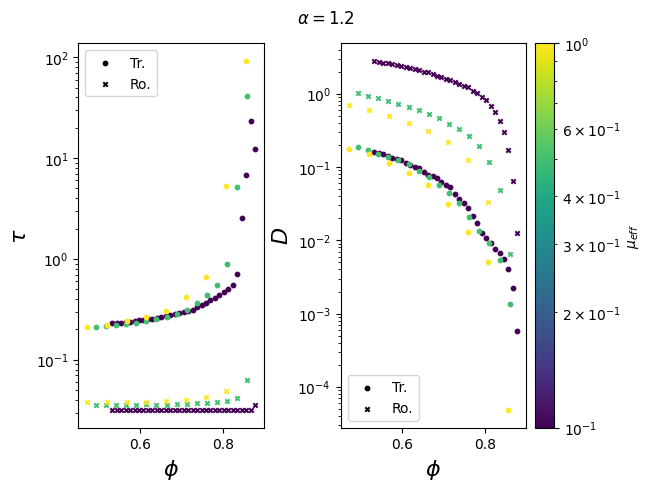

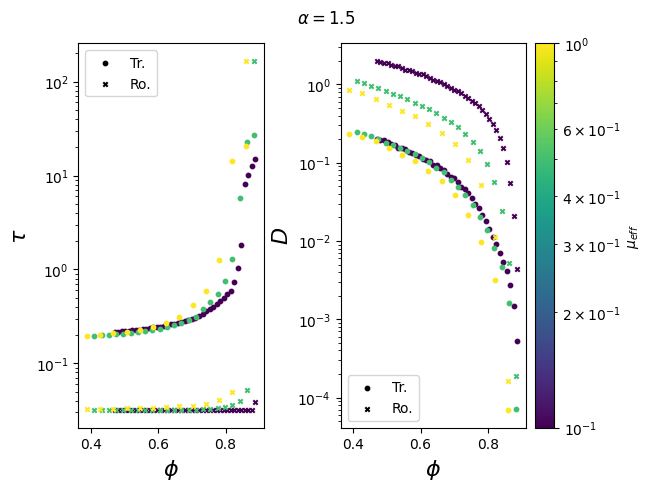

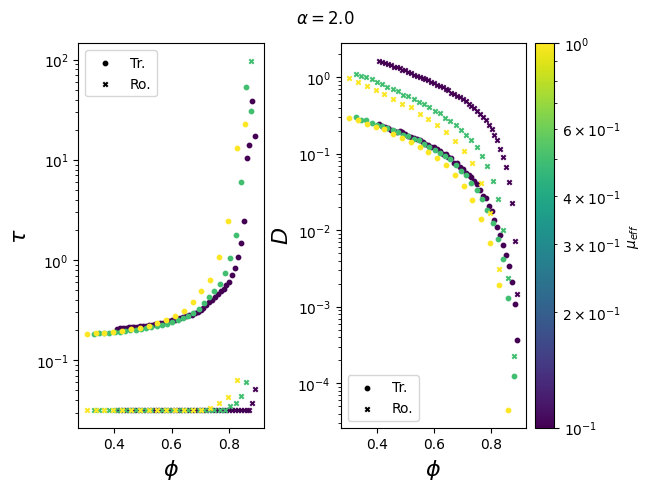

In [215]:
ga_tau = np.array([get_relaxation_time(isf, t * np.sqrt(temp)) for isf, t, temp in zip(ga_data['isf'], ga_data['t'], ga_data['temp'])])
ga_D = np.array([get_diffusion_coeff(msd, t * np.sqrt(temp)) for msd, t, temp in zip(ga_data['msd'], ga_data['t'], ga_data['temp'])])
ga_D[np.isnan(ga_tau)] = np.nan

ga_tau_R = np.array([get_relaxation_time(aisf, t * np.sqrt(temp)) for aisf, t, temp in zip(ga_data['aisf'], ga_data['t'], ga_data['temp'])])
ga_D_R = np.array([get_diffusion_coeff(msad, t * np.sqrt(temp)) for msad, t, temp in zip(ga_data['msad'], ga_data['t'], ga_data['temp'])])
ga_D_R[np.isnan(ga_tau_R)] = np.nan

alpha_norm = plt.Normalize(min(ga_data['alpha']), max(ga_data['alpha']))
mu_norm = LogNorm(min(ga_data['mu']), max(ga_data['mu']))
cmap = plt.cm.viridis

for alpha in np.unique(ga_data['alpha']):
    fig, ax = plt.subplots(1, 2, sharex=True, constrained_layout=True)
    for mu in np.unique(ga_data['mu']):
        ga_data_mask = (ga_data['mu'] == mu) & (ga_data['alpha'] == alpha)
        ax[0].scatter(ga_data_true_phi[ga_data_mask], ga_tau[ga_data_mask], c=cmap(mu_norm(mu)), s=10, marker='o')
        ax[0].scatter(ga_data_true_phi[ga_data_mask], ga_tau_R[ga_data_mask], c=cmap(mu_norm(mu)), s=10, marker='x')
        ax[1].scatter(ga_data_true_phi[ga_data_mask], ga_D[ga_data_mask], c=cmap(mu_norm(mu)), s=10, marker='o')
        ax[1].scatter(ga_data_true_phi[ga_data_mask], ga_D_R[ga_data_mask], c=cmap(mu_norm(mu)), s=10, marker='x')
    for a in ax:
        a.set_yscale('log')
        a.set_xlabel(r'$\phi$', fontsize=16)
        a.scatter([], [], marker='o', label='Tr.', c='k', s=10)
        a.scatter([], [], marker='x', label='Ro.', c='k', s=10)
        a.legend()
        
    ax[0].set_ylabel(r'$\tau$', fontsize=16)
    ax[1].set_ylabel(r'$D$', fontsize=16)

    sm = plt.cm.ScalarMappable(norm=mu_norm, cmap=cmap)
    sm.set_array(np.unique(ga_data['mu']))
    cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\mu_{eff}$')

    plt.suptitle(fr'$\alpha=${alpha}')
    plt.show()

# Disk Dynamics

/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_55392/1774674776.py:14: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[0].scatter(sphere_data['phi'][mask], sphere_tau[mask], c=cmap(temp_norm(temp)), marker=marker, s=10)
/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_55392/1774674776.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[1].scatter(sphere_data['phi'][mask], sphere_D[mask], c=cmap(tem

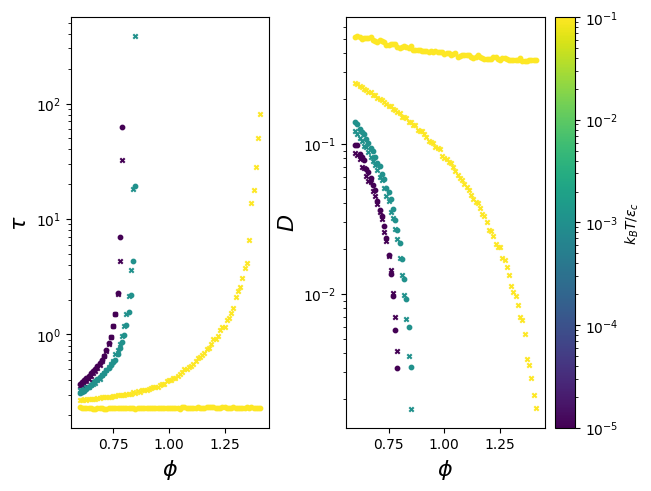

In [216]:
sphere_tau = np.array([get_relaxation_time(isf, t * np.sqrt(temp)) for isf, t, temp, min_save_decade in zip(sphere_data['isf'], sphere_data['t'], sphere_data['temp'], sphere_min_save_decade)])
sphere_D = np.array([get_diffusion_coeff(msd, t * np.sqrt(temp)) for msd, t, temp, min_save_decade in zip(sphere_data['msd'], sphere_data['t'], sphere_data['temp'], sphere_min_save_decade)])
sphere_D[np.isnan(sphere_tau)] = np.nan

temp_norm = LogNorm(min(sphere_data['temp']), max(sphere_data['temp']))
cmap = plt.cm.viridis

fig, ax = plt.subplots(1, 2, sharex=True, constrained_layout=True)

for which in np.unique(sphere_data['which']):
    marker = 'x' if 'wca' in which else 'o'
    for temp in np.unique(sphere_data['temp']):
        mask = (sphere_data['which'] == which) & (sphere_data['temp'] == temp)
        ax[0].scatter(sphere_data['phi'][mask], sphere_tau[mask], c=cmap(temp_norm(temp)), marker=marker, s=10)
        ax[1].scatter(sphere_data['phi'][mask], sphere_D[mask], c=cmap(temp_norm(temp)), marker=marker, s=10)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'$\phi$', fontsize=16)
ax[0].set_ylabel(r'$\tau$', fontsize=16)
ax[1].set_ylabel(r'$D$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=temp_norm, cmap=cmap)
sm.set_array(np.unique(sphere_data['temp']))
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$k_B T/ \varepsilon_c$')

# Disk Dynamics with True Density

/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_55392/3493486109.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[0].scatter(sphere_data['phi_true'][mask], sphere_tau[mask], c=cmap(temp_norm(temp)), marker=marker, s=10)
/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_55392/3493486109.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[1].scatter(sphere_data['phi_true'][mask], sphere_D[mask], 

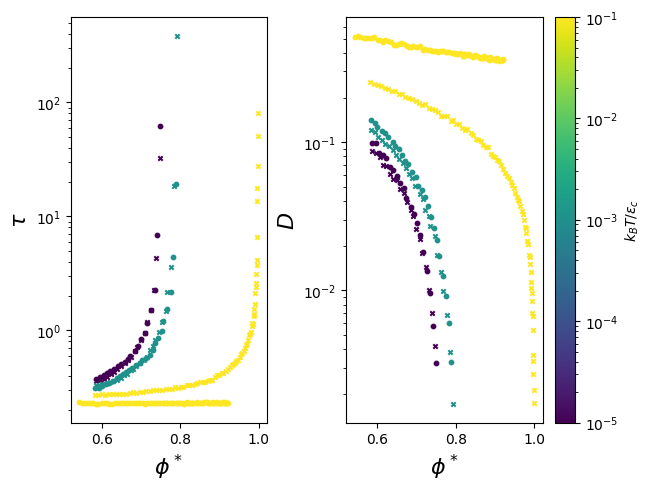

In [217]:
temp_norm = LogNorm(min(sphere_data['temp']), max(sphere_data['temp']))
cmap = plt.cm.viridis

fig, ax = plt.subplots(1, 2, sharex=True, constrained_layout=True)

for which in np.unique(sphere_data['which']):
    marker = 'x' if 'wca' in which else 'o'
    for temp in np.unique(sphere_data['temp']):
        mask = (sphere_data['which'] == which) & (sphere_data['temp'] == temp)
        ax[0].scatter(sphere_data['phi_true'][mask], sphere_tau[mask], c=cmap(temp_norm(temp)), marker=marker, s=10)
        ax[1].scatter(sphere_data['phi_true'][mask], sphere_D[mask], c=cmap(temp_norm(temp)), marker=marker, s=10)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'$\phi^*$', fontsize=16)
ax[0].set_ylabel(r'$\tau$', fontsize=16)
ax[1].set_ylabel(r'$D$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=temp_norm, cmap=cmap)
sm.set_array(np.unique(sphere_data['temp']))
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$k_B T/ \varepsilon_c$')

/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_55392/118561153.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[0].scatter(1 - sphere_data['phi_true'][mask], sphere_tau[mask], c=cmap(temp_norm(temp)), marker=marker, s=10)
/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_55392/118561153.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[1].scatter(1 - sphere_data['phi_true'][mask], sphere_D[m

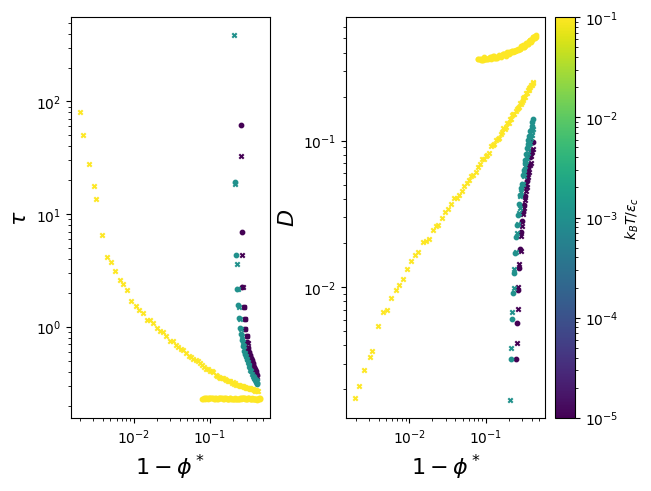

In [218]:
temp_norm = LogNorm(min(sphere_data['temp']), max(sphere_data['temp']))
cmap = plt.cm.viridis

fig, ax = plt.subplots(1, 2, sharex=True, constrained_layout=True)

for which in np.unique(sphere_data['which']):
    marker = 'x' if 'wca' in which else 'o'
    for temp in np.unique(sphere_data['temp']):
        mask = (sphere_data['which'] == which) & (sphere_data['temp'] == temp)
        ax[0].scatter(1 - sphere_data['phi_true'][mask], sphere_tau[mask], c=cmap(temp_norm(temp)), marker=marker, s=10)
        ax[1].scatter(1 - sphere_data['phi_true'][mask], sphere_D[mask], c=cmap(temp_norm(temp)), marker=marker, s=10)

for a in ax:
    a.set_yscale('log')
    a.set_xscale('log')
    a.set_xlabel(r'$1-\phi^*$', fontsize=16)
ax[0].set_ylabel(r'$\tau$', fontsize=16)
ax[1].set_ylabel(r'$D$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=temp_norm, cmap=cmap)
sm.set_array(np.unique(sphere_data['temp']))
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$k_B T/ \varepsilon_c$')

# Plotting GA and Disks Together

/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_55392/1218513457.py:14: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[0].scatter(sphere_data['phi'][mask], sphere_tau[mask], c=cmap(temp_norm(temp)), marker='o', s=10)
/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_55392/1218513457.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[1].scatter(sphere_data['phi'][mask], sphere_D[mask], c=cmap(temp_n

Text(0, 0.5, '$D$')

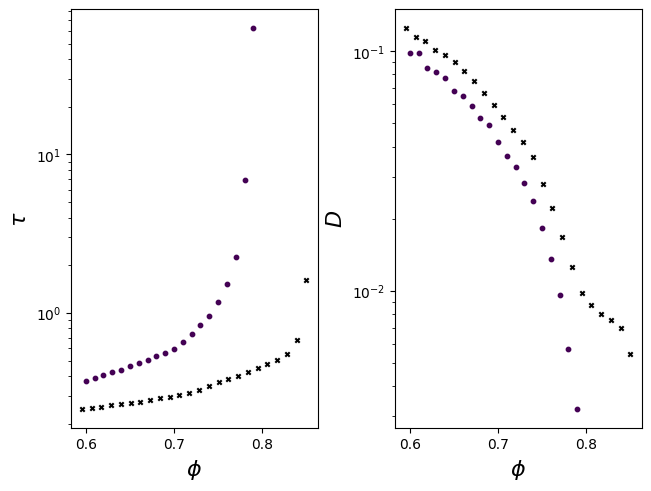

In [223]:
fig, ax = plt.subplots(1, 2, sharex=True, constrained_layout=True)

ga_data_mask = (ga_data['mu'] == 0.1) & (ga_data['alpha'] == 1.0)
ax[0].scatter(ga_data_true_phi[ga_data_mask], ga_tau[ga_data_mask], c='k', s=10, marker='x')
ax[1].scatter(ga_data_true_phi[ga_data_mask], ga_D[ga_data_mask], c='k', s=10, marker='x')

for which in np.unique(sphere_data['which']):
    if 'wca' in which:
        continue
    for temp in np.unique(sphere_data['temp']):
        if temp != 1e-5:
            continue
        mask = (sphere_data['which'] == which) & (sphere_data['temp'] == temp)
        ax[0].scatter(sphere_data['phi'][mask], sphere_tau[mask], c=cmap(temp_norm(temp)), marker='o', s=10)
        ax[1].scatter(sphere_data['phi'][mask], sphere_D[mask], c=cmap(temp_norm(temp)), marker='o', s=10)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'$\phi$', fontsize=16)
ax[0].set_ylabel(r'$\tau$', fontsize=16)
ax[1].set_ylabel(r'$D$', fontsize=16)


# DP Dynamics

/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_55392/555487204.py:21: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[0].scatter(dp_data['phi_true'][dp_mask], dp_tau[dp_mask], c=c, s=10, marker='o')
/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_55392/555487204.py:22: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[1].scatter(dp_data['phi_true'][dp_mask], dp_D[dp_mask], c=c, s=10, marker='o')


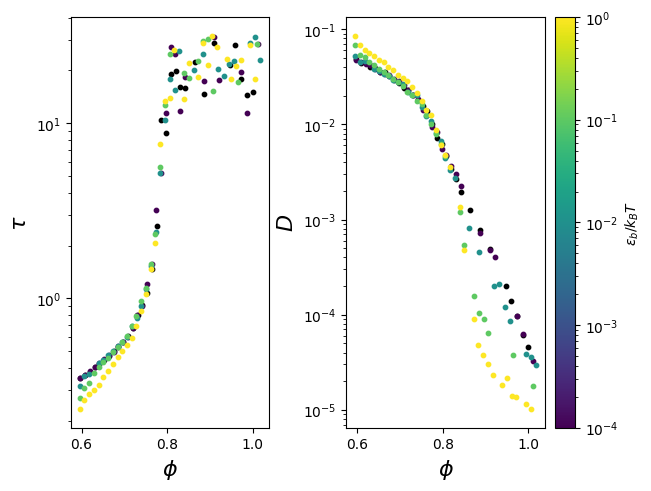

In [220]:
dp_tau = np.array([get_relaxation_time(isf, t * np.sqrt(temp)) for isf, t, temp in zip(dp_data['isf'], dp_data['t'], dp_data['temp'])])
dp_D = np.array([get_diffusion_coeff(msd, t * np.sqrt(temp)) for msd, t, temp in zip(dp_data['msd'], dp_data['t'], dp_data['temp'])])
dp_D[np.isnan(dp_tau)] = np.nan

eb = dp_data['eb'].copy()
eb = np.array([e if e else 0 for e in eb])

eb_norm = LogNorm(min(eb[eb > 0]), max(eb[eb > 0]))
cmap = plt.cm.viridis

fig, ax = plt.subplots(1, 2, sharex=True, constrained_layout=True)

for _eb in np.unique(eb):
    dp_mask = eb == _eb

    if _eb > 0:
        c = cmap(eb_norm(_eb))
    else:
        c = 'k'

    ax[0].scatter(dp_data['phi_true'][dp_mask], dp_tau[dp_mask], c=c, s=10, marker='o')
    ax[1].scatter(dp_data['phi_true'][dp_mask], dp_D[dp_mask], c=c, s=10, marker='o')

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'$\phi$', fontsize=16)
    
ax[0].set_ylabel(r'$\tau$', fontsize=16)
ax[1].set_ylabel(r'$D$', fontsize=16)


sm = plt.cm.ScalarMappable(norm=eb_norm, cmap=cmap)
sm.set_array(np.unique(_eb))
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\varepsilon_b / k_B T$')

# Plotting GA and DP Together

/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_55392/1947170492.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[0].scatter(dp_data['phi_true'][dp_mask], dp_tau[dp_mask], c=c, s=10, marker='o')
/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_55392/1947170492.py:20: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[1].scatter(dp_data['phi_true'][dp_mask], dp_D[dp_mask], c=c, s=10, marker='o')


Text(0, 0.5, '$D$')

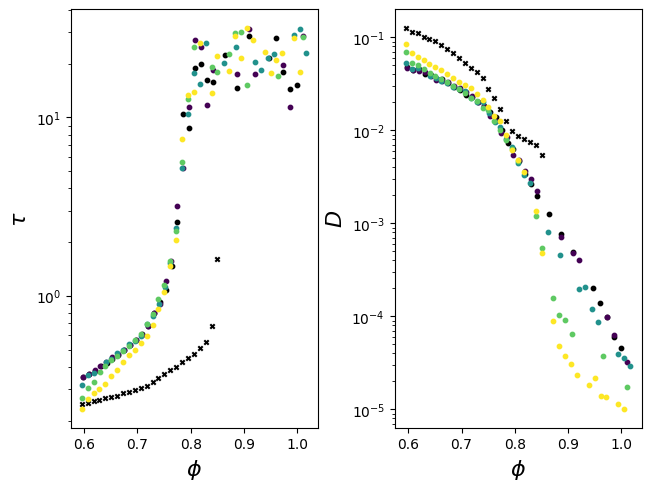

In [221]:
ga_data_mask = (ga_data['alpha'] == 1.0) & (ga_data['mu'] == 0.1)

fig, ax = plt.subplots(1, 2, sharex=True, constrained_layout=True)

ax[0].scatter(ga_data_true_phi[ga_data_mask], ga_tau[ga_data_mask], c='k', s=10, marker='x')
ax[1].scatter(ga_data_true_phi[ga_data_mask], ga_D[ga_data_mask], c='k', s=10, marker='x')

eb_norm = LogNorm(min(eb[eb > 0]), max(eb[eb > 0]))
cmap = plt.cm.viridis

for _eb in np.unique(eb):
    dp_mask = eb == _eb

    if _eb > 0:
        c = cmap(eb_norm(_eb))
    else:
        c = 'k'

    ax[0].scatter(dp_data['phi_true'][dp_mask], dp_tau[dp_mask], c=c, s=10, marker='o')
    ax[1].scatter(dp_data['phi_true'][dp_mask], dp_D[dp_mask], c=c, s=10, marker='o')

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'$\phi$', fontsize=16)
    
ax[0].set_ylabel(r'$\tau$', fontsize=16)
ax[1].set_ylabel(r'$D$', fontsize=16)


# Disk Berthier Diagrams

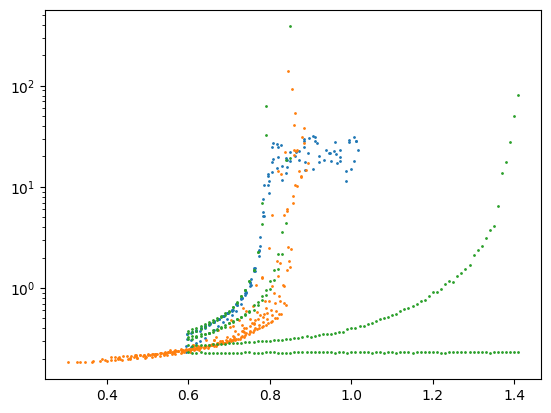

In [65]:
data = dp_data

plt.scatter(data['phi_true'], [get_relaxation_time(isf, t * np.sqrt(temp)) for isf, t, temp in zip(data['isf'], data['t'], data['temp'])], s=1)

data = ga_data

plt.scatter(ga_data_true_phi, [get_relaxation_time(isf, t * np.sqrt(temp)) for isf, t, temp in zip(data['isf'], data['t'], data['temp'])], s=1)

data = sphere_data

plt.scatter(data['phi'], [get_relaxation_time(isf, t * np.sqrt(temp)) for isf, t, temp in zip(data['isf'], data['t'], data['temp'])], s=1)

plt.yscale('log')


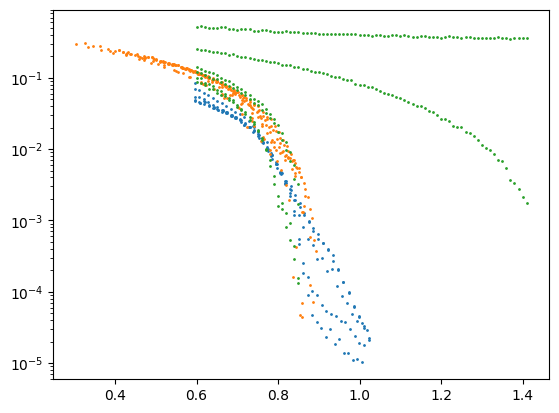

In [66]:
data = dp_data

plt.scatter(data['phi_true'], [get_diffusion_coeff(msd, t * np.sqrt(temp)) for msd, t, temp in zip(data['msd'], data['t'], data['temp'])], s=1)

data = ga_data

plt.scatter(ga_data_true_phi, [get_diffusion_coeff(msd, t * np.sqrt(temp)) for msd, t, temp in zip(data['msd'], data['t'], data['temp'])], s=1)

data = sphere_data

plt.scatter(data['phi'], [get_diffusion_coeff(msd, t * np.sqrt(temp)) for msd, t, temp in zip(data['msd'], data['t'], data['temp'])], s=1)

plt.yscale('log')


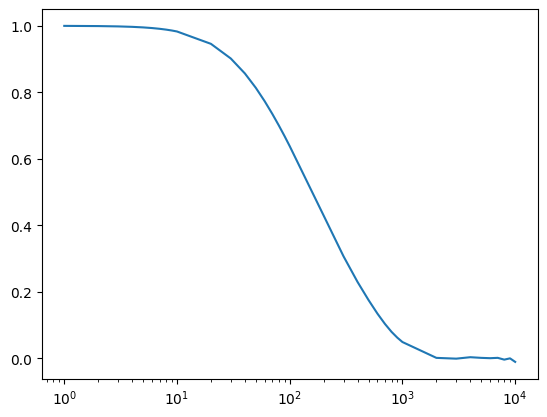

In [ ]:
data = dp_data

for i in range(len(data['isf'])):
    t = data['t'][i]
    isf = data['isf'][i]
    msd = data['msd'][i]
    plt.plot(t, isf)
    plt.xscale('log')
    break